In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

In [2]:
import neuroboros as nb
import numpy as np
from scipy.stats import ttest_rel

In [3]:
results = nb.load('summary/isc_camcan.pkl')

In [4]:
list(results)

[('young', 'young'),
 ('mid', 'young'),
 ('old', 'young'),
 ('young', 'mid'),
 ('mid', 'mid'),
 ('old', 'mid'),
 ('young', 'old'),
 ('mid', 'old'),
 ('old', 'old')]

In [5]:
for test_grp in ['old', 'young']:
    for tpl_grp in ['old', 'young']:
        print(results[test_grp, tpl_grp].shape)

(10, 72, 19341)
(10, 72, 19341)
(10, 71, 19341)
(10, 71, 19341)


In [6]:
test_lists = nb.load('summary/camcan_test_lists.pkl')

In [7]:
zz = {}
for test_grp in ['old', 'young']:
    for tpl_grp in ['old', 'young']:
        sid_results = {}
        for trial in range(10):
            sids = test_lists[test_grp, trial]
            vals = results[test_grp, tpl_grp][trial]
            for sid, val in zip(sids, vals):
                if sid not in sid_results:
                    sid_results[sid] = []
                sid_results[sid].append(val)
        res = [np.mean(np.arctanh(sid_results[sid]), axis=0) for sid in sid_results]
        print(np.unique([len(sid_results[sid]) for sid in sid_results], return_counts=True))
        res = np.stack(res, axis=0)
        print(res.shape)
        zz[test_grp, tpl_grp] = res.mean(axis=0)

(array([1, 2, 3, 4, 5, 6, 7, 8]), array([18, 43, 55, 51, 33, 10,  2,  1]))
(213, 19341)
(array([1, 2, 3, 4, 5, 6, 7, 8]), array([18, 43, 55, 51, 33, 10,  2,  1]))
(213, 19341)
(array([1, 2, 3, 4, 5, 6, 8]), array([19, 37, 62, 48, 27, 16,  1]))
(210, 19341)
(array([1, 2, 3, 4, 5, 6, 8]), array([19, 37, 62, 48, 27, 16,  1]))
(210, 19341)


In [50]:
a = np.tanh(zz['old', 'old'])
b = np.tanh(zz['old', 'young'])
c = zz['old', 'old'] - zz['old', 'young']
for d in [a, b, c]:
    nb.percentile(d)

[0.15181013 0.48520611 0.52053091 0.54742034 0.57178464 0.59521294
 0.62221857 0.64502053 0.66719856 0.69631931 0.7712949 ]
[0.1352128  0.46003639 0.50194964 0.5310375  0.5571427  0.58360433
 0.61037178 0.63516208 0.66000972 0.69077324 0.77049123]
[-0.25823029 -0.04926842 -0.02649102 -0.01102953  0.00249482  0.01569967
  0.02920681  0.04441498  0.0641238   0.09405785  0.38510243]


In [51]:
vmax = 1
ia = nb.plot(a, vmax=vmax, vmin=-vmax, cmap='bwr', title = "ISC of older adults (congruent)", label='$r$')
ib = nb.plot(b, vmax=vmax, vmin=-vmax, cmap='bwr', title = "ISC of older adults (incongruent)", label='$r$')
vmax = 0.5
ic = nb.plot(c, vmax=vmax, vmin=-vmax, cmap='bwr', title = "ISC difference (congruent - incongruent)", label='$z$ difference')
nb.Image.hstack([ia, ib, ic]).save('figures/isc_map_camcan_older.png')

In [48]:
a = np.tanh(zz['young', 'young'])
b = np.tanh(zz['young', 'old'])
c = zz['young', 'young'] - zz['young', 'old']
for d in [a, b, c]:
    nb.percentile(d)

[0.17059003 0.53379257 0.59523056 0.63204767 0.66309703 0.69299873
 0.7209308  0.74611827 0.77408154 0.81443463 0.87152315]
[0.12842489 0.52735966 0.58484318 0.62022581 0.65022232 0.67866533
 0.7083553  0.73489577 0.76243691 0.80230782 0.86731607]
[-0.3235585  -0.05362242 -0.02873437 -0.0109114   0.00430057  0.01802658
  0.03289124  0.04982708  0.07188055  0.10608525  0.51015593]


In [49]:
vmax = 1
ia = nb.plot(a, vmax=vmax, vmin=-vmax, cmap='bwr', title = "ISC of younger adults (congruent)", label='$r$')
ib = nb.plot(b, vmax=vmax, vmin=-vmax, cmap='bwr', title = "ISC of younger adults (incongruent)", label='$r$')
vmax = 0.5
ic = nb.plot(c, vmax=vmax, vmin=-vmax, cmap='bwr', title = "ISC difference (congruent - incongruent)", label='$z$ difference')
nb.Image.hstack([ia, ib, ic]).save('figures/isc_map_camcan_younger.png')

[-0.05674339 -0.00722824 -0.00214112  0.00137143  0.004274    0.00714408
  0.01037117  0.01404768  0.01874096  0.02620566  0.11565835]


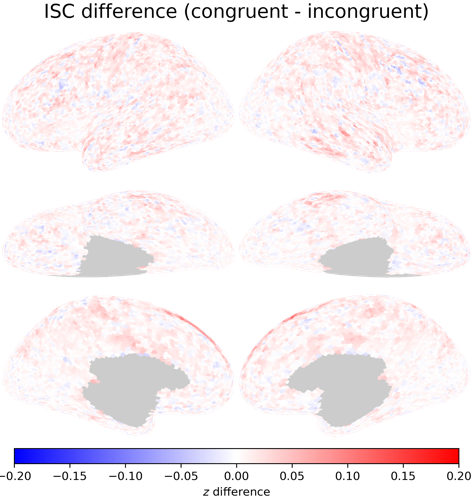

In [53]:
c = ((zz['young', 'young'] - zz['young', 'old']) + (zz['old', 'old'] - zz['old', 'young'])) * 0.2
nb.percentile(c)
vmax = 0.2
ic = nb.plot(c, vmax=vmax, vmin=-vmax, cmap='bwr', title = "ISC difference (congruent - incongruent)", label='$z$ difference')
ic.save('figures/isc_map_camcan_average.png')
ic

In [54]:
mako = np.array(sns.color_palette('mako', 7))
rocket = np.array(sns.color_palette('rocket', 7))
colors = np.concatenate([
    mako[1:],
    [mako[-1] * 0.5 + 0.5],
    [[1, 1, 1]],
    [rocket[-1] * 0.5 + 0.5],
    rocket[1:][::-1],
])
print(colors)
# cmap = mpl.colors.ListedColormap(colors)
cmap = mpl.colors.LinearSegmentedColormap.from_list('mako_rocket', list(colors))

[[0.24423453 0.20678459 0.41985299]
 [0.23318874 0.33648036 0.59775543]
 [0.20692679 0.48201774 0.63812656]
 [0.20795035 0.62210845 0.66867802]
 [0.29215894 0.76144162 0.67886578]
 [0.60028928 0.86793835 0.71523675]
 [0.80014464 0.93396917 0.85761837]
 [1.         1.         1.        ]
 [0.98296414 0.86922129 0.80026995]
 [0.96592829 0.73844258 0.60053991]
 [0.95922872 0.53307513 0.3748895 ]
 [0.92676657 0.29823282 0.24285536]
 [0.7965014  0.10506637 0.31063031]
 [0.59096382 0.10810205 0.35847347]
 [0.38092887 0.12061482 0.32506528]]


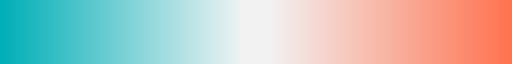

In [71]:
cmap = sns.diverging_palette(200, 20, s=100, l=65, sep=16, as_cmap=True)
cmap

[-0.05674339 -0.00722824 -0.00214112  0.00137143  0.004274    0.00714408
  0.01037117  0.01404768  0.01874096  0.02620566  0.11565835]


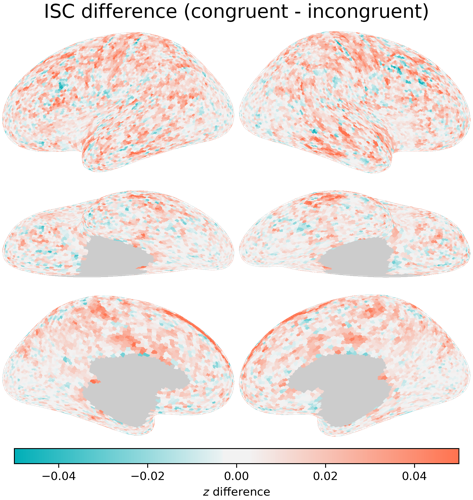

In [72]:
c = ((zz['young', 'young'] - zz['young', 'old']) + (zz['old', 'old'] - zz['old', 'young'])) * 0.2
nb.percentile(c)
vmax = 0.05
ic = nb.plot(c, vmax=vmax, vmin=-vmax, cmap=cmap, title = "ISC difference (congruent - incongruent)", label='$z$ difference')
ic.save('figures/isc_map_camcan_average.png')
ic

In [60]:
sns.diverging_palette?

Signature:
sns.diverging_palette(
    h_neg,
    h_pos,
    s=75,
    l=50,
    sep=1,
    n=6,
    center='light',
    as_cmap=False,
)
Docstring:
Make a diverging palette between two HUSL colors.

If you are using the IPython notebook, you can also choose this palette
interactively with the :func:`choose_diverging_palette` function.

Parameters
----------
h_neg, h_pos : float in [0, 359]
    Anchor hues for negative and positive extents of the map.
s : float in [0, 100], optional
    Anchor saturation for both extents of the map.
l : float in [0, 100], optional
    Anchor lightness for both extents of the map.
sep : int, optional
    Size of the intermediate region.
n : int, optional
    Number of colors in the palette (if not returning a cmap)
center : {"light", "dark"}, optional
    Whether the center of the palette is light or dark
as_cmap : bool, optional
    If True, return a :class:`matplotlib.colors.ListedColormap`.

Returns
-------
palette
    list of RGB tuples or :class:`ma